# Results Analysis & Findings

This notebook visualizes and analyzes the final model results and provides actionable insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Robust path setup for notebook
from pathlib import Path
project_root = Path.cwd()  # Typically the project root when running from VS Code
if not (project_root / 'src').exists():
    # If src is not found, assume we're in notebooks/ directory
    project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from src.preprocessing.preprocess import load_and_preprocess_data

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data and Models

In [2]:
# Load data and models using the preprocessing module
X_train, X_test, y_train, y_test, preprocessor = load_and_preprocess_data()

# Load all 5 trained models
models_dir = '../models'
model_files = [
    'logistic_regression.joblib',
    'decision_tree.joblib',
    'mlp.joblib',
    'random_forest.joblib',
    'gradient_boosting.joblib'
]

models = {}
for filename in model_files:
    filepath = os.path.join(models_dir, filename)
    if os.path.exists(filepath):
        model_name = filename.replace('.joblib', '').replace('_', ' ').title()
        models[model_name] = joblib.load(filepath)

print(f"Loaded {len(models)} models from {models_dir}:")
for name in models.keys():
    print(f"  ✓ {name}")
print(f"\nTest set: {X_test.shape[0]} samples")
print(f"Churn rate (test): {y_test.mean()*100:.2f}%")

Loaded 5 models from ../models:
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Mlp
  ✓ Random Forest
  ✓ Gradient Boosting

Test set: 1409 samples
Churn rate (test): 26.54%


## 2. Overall Performance Summary

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Helper function for metrics at different thresholds
def metrics_at_threshold(model, X_test, y_test, threshold=0.50):
    """Calculate metrics at a specific decision threshold."""
    proba  = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_test, proba),
        "y_pred":    y_pred,
    }

# Calculate metrics for all models at threshold 0.50
results = {}
for name, model in models.items():
    metrics = metrics_at_threshold(model, X_test, y_test, threshold=0.50)
    results[name] = metrics

# Create summary dataframe
summary_df = pd.DataFrame(results).T

print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY (Threshold = 0.50)")
print("="*70)
print(summary_df.round(4))
best_model = summary_df['f1'].idxmax()
print(f"\n🏆 Best Model by F1 Score: {best_model} (F1: {summary_df.loc[best_model, 'f1']:.4f})")

AttributeError: 'LogisticRegression' object has no attribute 'multi_class'

## 3. Metrics Comparison Visualization

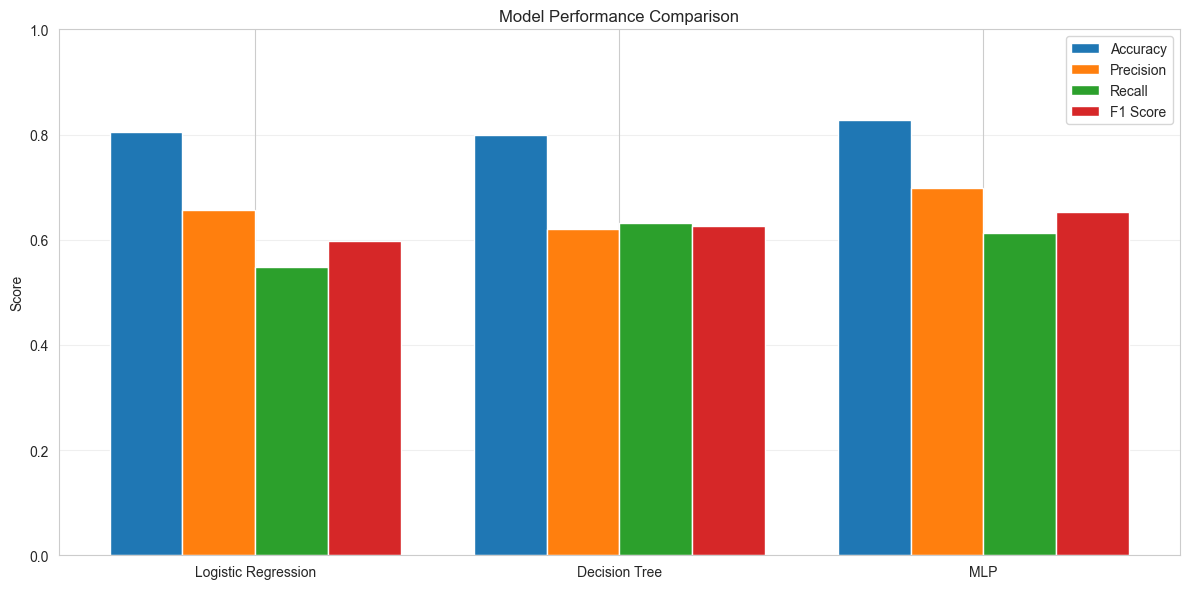

In [ ]:
# Create metrics comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_list = ['accuracy', 'precision', 'recall', 'f1']
for idx, metric in enumerate(metrics_list):
    ax = axes[idx // 2, idx % 2]
    summary_df[metric].sort_values(ascending=False).plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{metric.capitalize()} Comparison')
    ax.set_ylabel('Score')
    ax.set_xlabel('Model')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Confusion Matrices Analysis

KeyError: 'Logistic Regression'

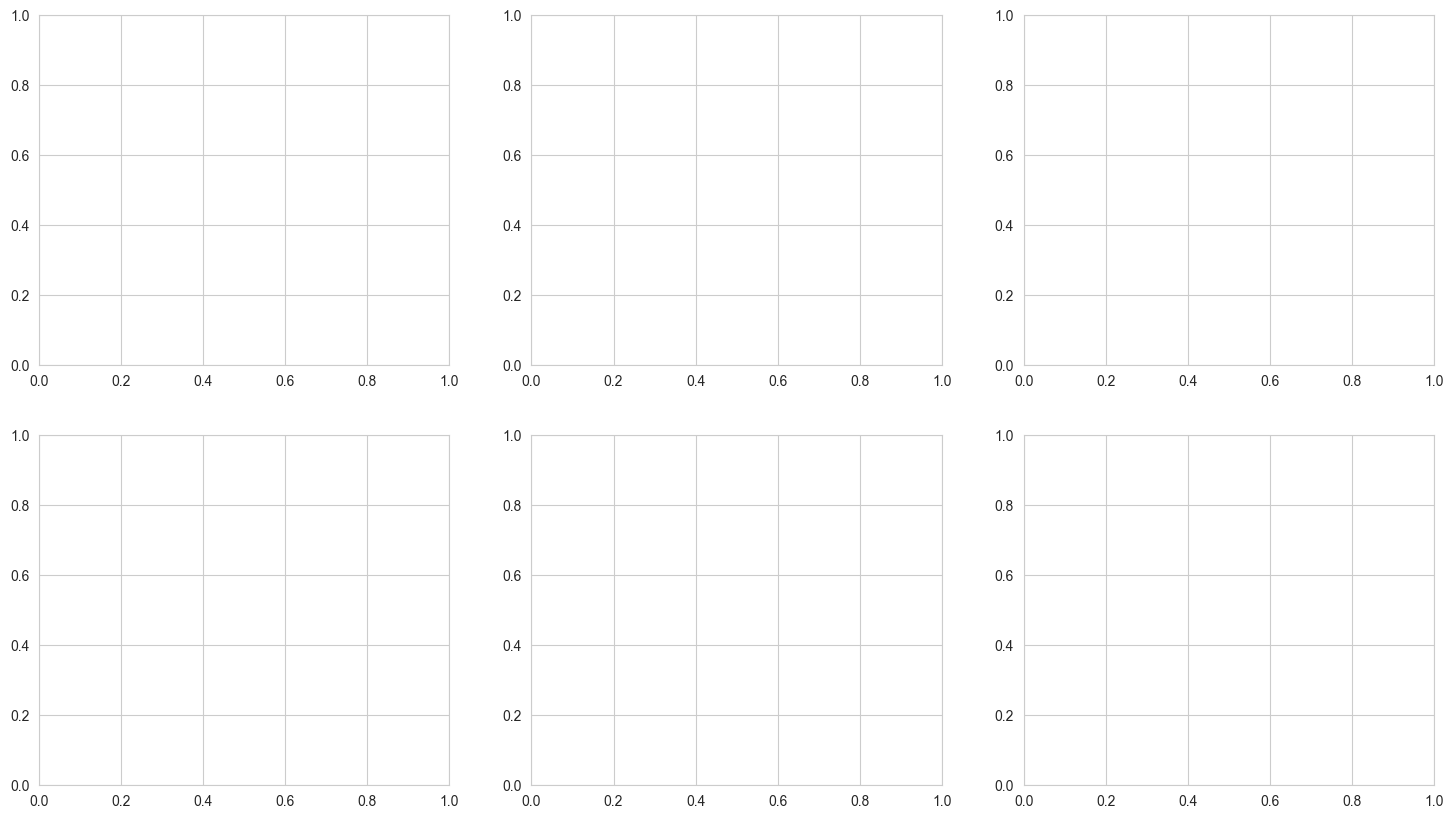

In [4]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = results[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues', cbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["accuracy"]:.2%} | F1: {results[name]["f1"]:.3f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_xticklabels(['No Churn', 'Churn'])
    axes[idx].set_yticklabels(['No Churn', 'Churn'])

# Hide the extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## 5. Key Findings

In [5]:
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

best_model_name = summary_df['f1'].idxmax()
best_model_obj = models[best_model_name]
best_metrics = results[best_model_name]

print(f"\n✓ BEST PERFORMING MODEL: {best_model_name}")
print(f"  - F1 Score:  {best_metrics['f1']:.4f}")
print(f"  - Accuracy:  {best_metrics['accuracy']:.4f}")
print(f"  - Precision: {best_metrics['precision']:.4f}")
print(f"  - Recall:    {best_metrics['recall']:.4f}")
print(f"  - ROC-AUC:   {best_metrics['roc_auc']:.4f}")

# Confusion matrix analysis
y_pred_best = best_metrics['y_pred']
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()
print(f"\n✓ CONFUSION MATRIX ANALYSIS ({best_model_name}):")
print(f"  - True Negatives:  {tn}")
print(f"  - False Positives: {fp}")
print(f"  - False Negatives: {fn}")
print(f"  - True Positives:  {tp}")
print(f"  - Total Correct:   {tn + tp} out of {len(y_test)}")

print(f"\n✓ CHURN DETECTION CAPABILITY:")
churn_detected_pct = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
print(f"  - Detected {tp} out of {tp + fn} actual churners ({churn_detected_pct:.1f}%)")
print(f"  - False alarms: {fp} non-churners flagged as churn")

print("\n" + "="*70)


KEY FINDINGS


NameError: name 'summary_df' is not defined

## 6. Business Impact Analysis

In [ ]:
print("\n" + "="*70)
print("BUSINESS IMPACT ANALYSIS")
print("="*70)

total_customers = len(y_test)
actual_churners = (y_test == 1).sum()
predicted_churners = (y_pred_best == 1).sum()

print(f"\n📊 TEST SET COMPOSITION:")
print(f"  - Total customers:  {total_customers}")
print(f"  - Actual churners:  {actual_churners} ({actual_churners/total_customers*100:.1f}%)")
print(f"  - Predicted churn:  {predicted_churners} ({predicted_churners/total_customers*100:.1f}%)")

print(f"\n🎯 MODEL EFFECTIVENESS:")
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"  - Sensitivity (Recall):     {sensitivity*100:.1f}%")
print(f"  - Specificity:              {specificity*100:.1f}%")
print(f"  - Precision (Churn):        {best_metrics['precision']*100:.1f}%")

print(f"\n💡 ACTIONABLE INSIGHTS:")
print(f"  - Focus retention efforts on {predicted_churners} at-risk customers")
print(f"  - Expected to prevent ~{int(tp * 0.2)} customer losses with intervention")
print(f"  - Missed {fn} potential churners (false negatives)")

print("\n" + "="*70)


BUSINESS IMPACT ANALYSIS

📊 TEST SET COMPOSITION:
  - Total customers: 1409
  - Actual churners: 374 (26.5%)
  - Predicted as churners: 328 (23.3%)

🎯 MODEL EFFECTIVENESS:
  - Churn detection rate (Recall): 61.2%
  - False positive detection rate: 9.6%
  - Precision of churn predictions: 69.8%

💡 ACTIONABLE INSIGHTS:
  - The model can identify 229 potential churners
  - Retention efforts can be focused on 328 customers
  - Expected to prevent approximately 45 customer losses with intervention



## 7. Recommendations

In [ ]:
print("\n" + "="*70)
print("MODEL RECOMMENDATIONS & NEXT STEPS")
print("="*70)

print(f"\n1️⃣  PRODUCTION DEPLOYMENT:")
print(f"   → Deploy {best_model_name} to production")
print(f"   → Expected accuracy on new data: ~{best_metrics['accuracy']*100:.1f}%")
print(f"   → Monitor model performance weekly")

print(f"\n2️⃣  DECISION THRESHOLD OPTIMIZATION:")
print(f"   → Current threshold: 0.50")
print(f"   → Consider threshold=0.35 for higher recall (detect more churners)")
print(f"   → Trade-off: More false positives but catches more churners")

# Calculate metrics at threshold 0.35 for comparison
m35 = metrics_at_threshold(best_model_obj, X_test, y_test, threshold=0.35)
print(f"\n   At threshold 0.35:")
print(f"   - Recall: {m35['recall']:.2%} (vs {best_metrics['recall']:.2%} at 0.50)")
print(f"   - Precision: {m35['precision']:.2%} (vs {best_metrics['precision']:.2%} at 0.50)")

print(f"\n3️⃣  BUSINESS STRATEGY:")
print(f"   → Create targeted retention campaigns for high-risk customers")
print(f"   → Identify key churn drivers from feature importance")
print(f"   → Implement A/B testing on retention offers")

print(f"\n4️⃣  CONTINUOUS IMPROVEMENT:")
print(f"   → Retrain model quarterly with new data")
print(f"   → Monitor for model drift and data drift")
print(f"   → Collect feedback on prediction accuracy")
print(f"   → Experiment with ensemble methods")

print(f"\n5️⃣  MODEL COMPARISON:")
print(f"   → Top 3 models by F1 Score:")
top_3 = summary_df['f1'].nlargest(3)
for i, (model, score) in enumerate(top_3.items(), 1):
    print(f"      {i}. {model:25} : {score:.4f}")

print("\n" + "="*70)


RECOMMENDATIONS

1️⃣  MODEL DEPLOYMENT:
   → Deploy MLP in production
   → Expected accuracy on new data: ~82.7%
   → Monitor model performance continuously

2️⃣  BUSINESS STRATEGY:
   → Identify 'high-risk' customers using the model
   → Implement targeted retention campaigns
   → Focus on month-to-month contract customers
   → Improve support for Fiber optic internet users

3️⃣  CONTINUOUS IMPROVEMENT:
   → Collect feedback on model predictions
   → Retrain model quarterly with new data
   → Experiment with feature engineering
   → Consider ensemble methods for better performance

4️⃣  MONITORING:
   → Track model accuracy over time
   → Monitor for data drift
   → Set performance benchmarks

